<a href="https://colab.research.google.com/github/naeni6v6/ecommerce-sales-analysis/blob/main/ecommerce_rfm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce RFM Analysis Portfolio

This notebook consolidates the useful analysis logic from the original notebooks into one clean, executable workflow.

## Project Goal
- Analyze e-commerce transaction data
- Identify key sales and profit drivers
- Segment customers with **RFM analysis**
- Propose business actions for revenue growth

## Notes on consolidation
- The original notebooks contained duplicated cells, out-of-order execution, and one notebook built on a different dataset.
- For portfolio quality, this file keeps the **relevant e-commerce analysis**, removes broken or unrelated parts, and reorganizes the work into a single narrative.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv(r'/mnt/data/ecommerce_sales_34500.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0, 19, 29, 39, 49, 59, 200],
    labels=['10s', '20s', '30s', '40s', '50s', '60+']
)
print(df.shape)
df.head()


Matplotlib is building the font cache; this may take a moment.


(34500, 18)


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,age_group
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female,60+
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male,30s
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male,30s
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female,20s
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male,30s


## 1. Data Overview

This dataset contains transaction-level e-commerce records, including:
- product category
- price, discount, quantity
- payment method
- order date and delivery time
- region
- return status
- total amount and profit margin
- customer age and gender


In [ ]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
summary


,dtype,missing_values,missing_pct
order_id,object,0,0.0
customer_id,object,0,0.0
product_id,object,0,0.0
category,object,0,0.0
price,float64,0,0.0
discount,float64,0,0.0
quantity,int64,0,0.0
payment_method,object,0,0.0
order_date,datetime64[ns],0,0.0
delivery_time_days,int64,0,0.0


In [ ]:
data_quality = {
    'rows': len(df),
    'columns': df.shape[1],
    'date_start': df['order_date'].min().date(),
    'date_end': df['order_date'].max().date(),
    'duplicate_order_ids': int(df['order_id'].duplicated().sum()),
    'total_missing_values': int(df.isna().sum().sum())
}
data_quality


{'rows': 34500,
 'columns': 18,
 'date_start': datetime.date(2023, 9, 12),
 'date_end': datetime.date(2025, 9, 11),
 'duplicate_order_ids': 0,
 'total_missing_values': 0}

## 2. Exploratory Data Analysis

The original notebooks contained separate EDA fragments.  
This section preserves the useful parts in one flow.


In [ ]:
def iqr_outlier_stats(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    outlier_pct = (series > upper).mean() * 100
    return round(q1, 2), round(q3, 2), round(upper, 2), round(outlier_pct, 2)

outlier_rows = []
for col in ['price', 'total_amount']:
    q1, q3, upper, outlier_pct = iqr_outlier_stats(df[col])
    outlier_rows.append({
        'variable': col,
        'Q1': q1,
        'Q3': q3,
        'upper_bound_IQR': upper,
        'outlier_pct': outlier_pct
    })

pd.DataFrame(outlier_rows)


,variable,Q1,Q3,upper_bound_IQR,outlier_pct
0,price,16.69,130.95,302.34,10.53
1,total_amount,19.71,168.53,391.76,10.99


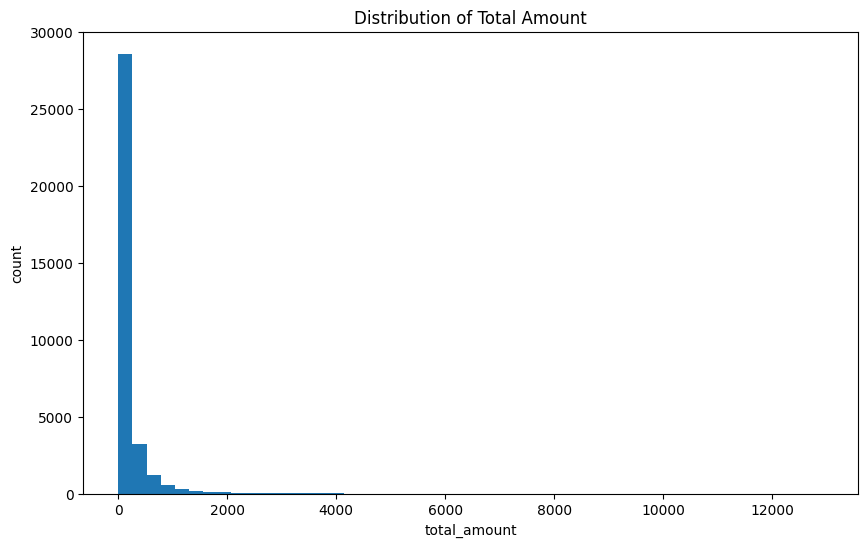

In [ ]:
plt.figure()
plt.hist(df['total_amount'], bins=50)
plt.title('Distribution of Total Amount')
plt.xlabel('total_amount')
plt.ylabel('count')
plt.show()


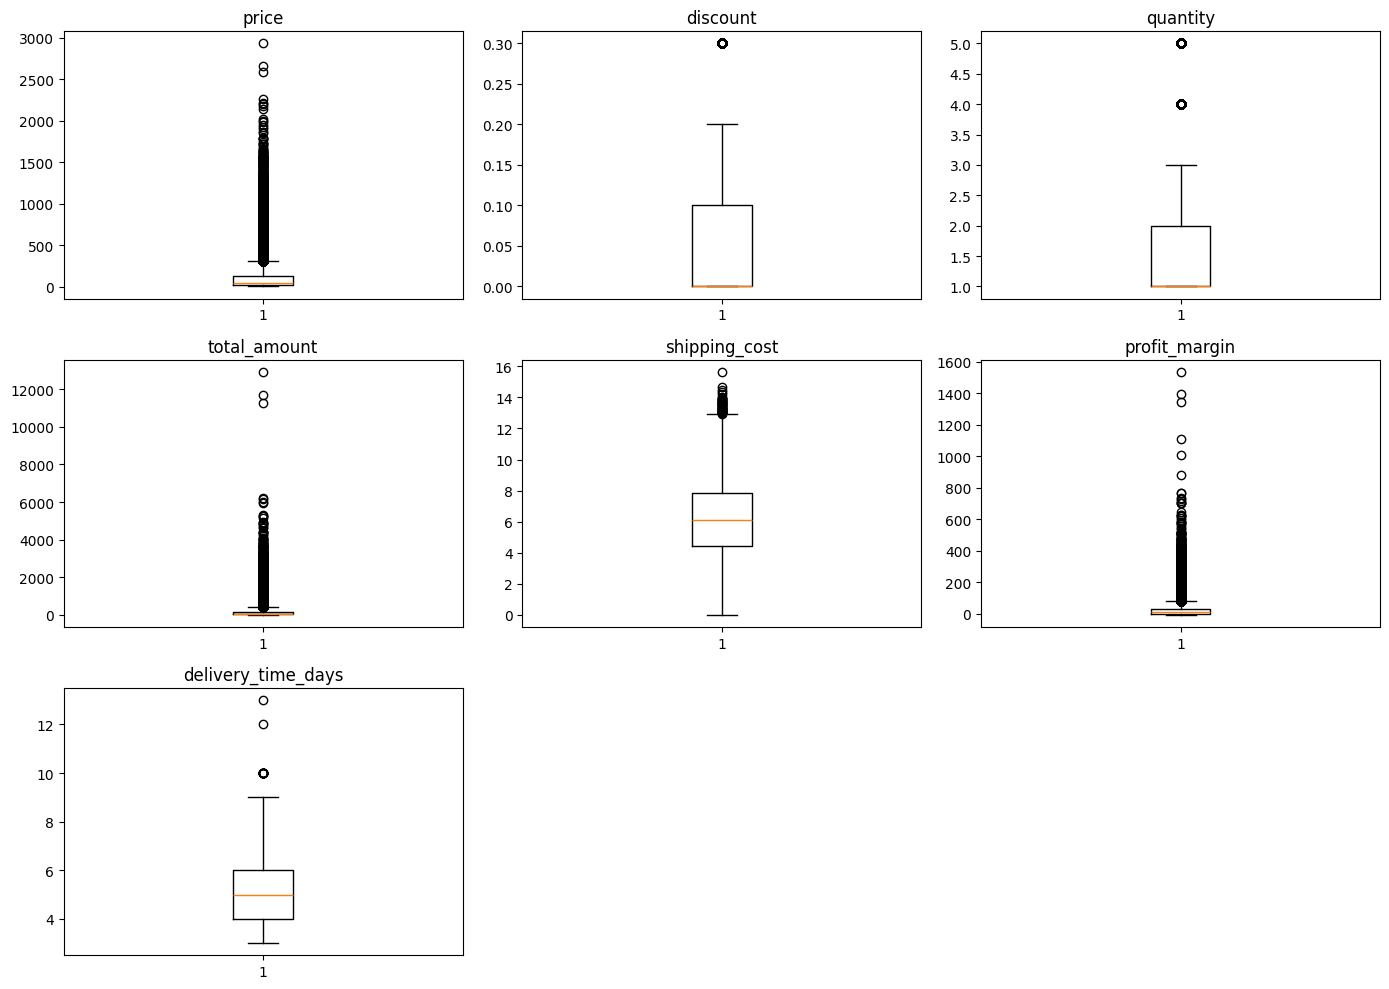

In [ ]:
numeric_cols = ['price', 'discount', 'quantity', 'total_amount', 'shipping_cost', 'profit_margin', 'delivery_time_days']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
region_avg = (
    df.groupby('region', as_index=False)['total_amount']
      .mean()
      .sort_values('total_amount', ascending=False)
)
region_avg


,region,total_amount
4,West,174.258299
3,South,171.162456
1,East,170.384523
0,Central,166.992788
2,North,166.931900


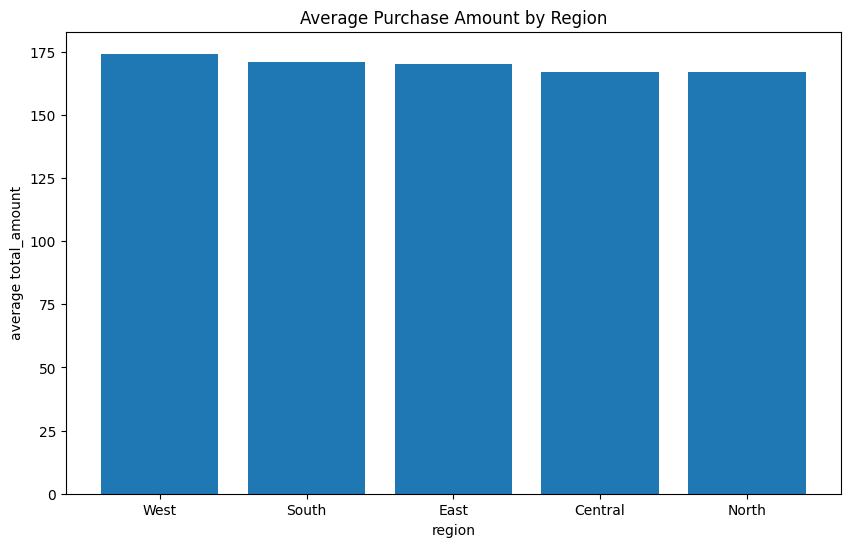

In [ ]:
plt.figure()
plt.bar(region_avg['region'], region_avg['total_amount'])
plt.title('Average Purchase Amount by Region')
plt.xlabel('region')
plt.ylabel('average total_amount')
plt.show()


In [ ]:
category_orders = (
    df.groupby('category', as_index=False)['order_id']
      .nunique()
      .sort_values('order_id', ascending=False)
)
category_orders


,category,order_id
2,Fashion,6254
1,Electronics,6180
4,Home,5487
6,Toys,4247
5,Sports,4171
0,Beauty,4103
3,Grocery,4058


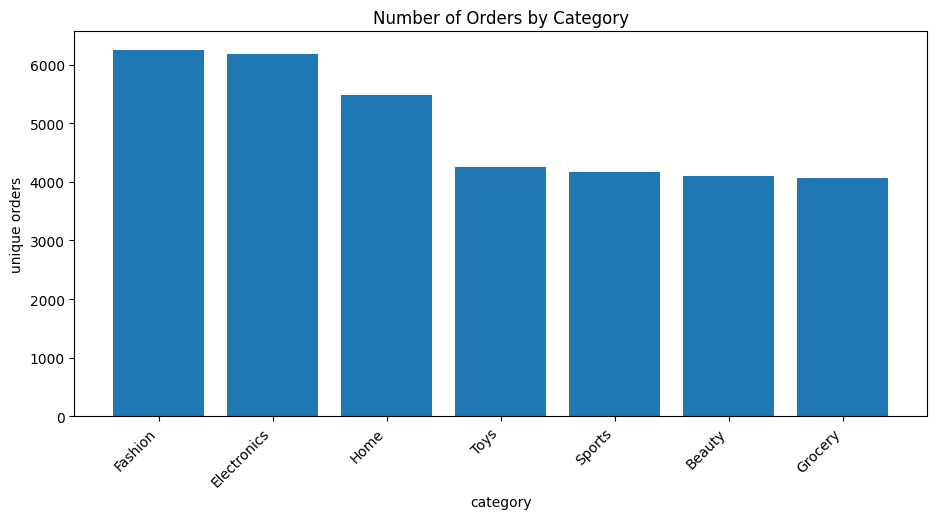

In [ ]:
plt.figure(figsize=(11, 5))
plt.bar(category_orders['category'], category_orders['order_id'])
plt.title('Number of Orders by Category')
plt.xlabel('category')
plt.ylabel('unique orders')
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
gender_share = (
    df.groupby('customer_gender')['total_amount']
      .sum()
      .div(df['total_amount'].sum())
      .mul(100)
      .round(1)
      .sort_values(ascending=False)
)
gender_share


customer_gender
Female    48.6
Male      47.6
Other      3.7
Name: total_amount, dtype: float64

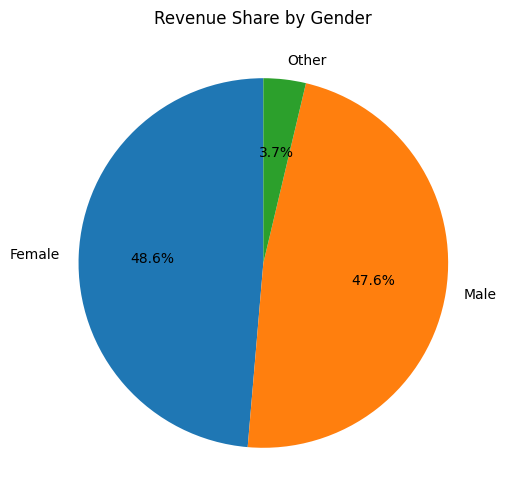

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(gender_share.values, labels=gender_share.index, autopct='%1.1f%%', startangle=90)
plt.title('Revenue Share by Gender')
plt.show()


In [ ]:
age_stats = (
    df.groupby('age_group', observed=False)
      .agg(
          avg_purchase_amount=('total_amount', 'mean'),
          order_count=('order_id', 'count'),
          total_revenue=('total_amount', 'sum')
      )
      .reset_index()
)
age_stats


,age_group,avg_purchase_amount,order_count,total_revenue
0,10s,174.857776,1322,231161.98
1,20s,176.860088,6626,1171874.94
2,30s,169.391791,6656,1127471.76
3,40s,169.400643,6689,1133120.90
4,50s,167.448042,6594,1104152.39
5,60+,165.962661,6613,1097511.08


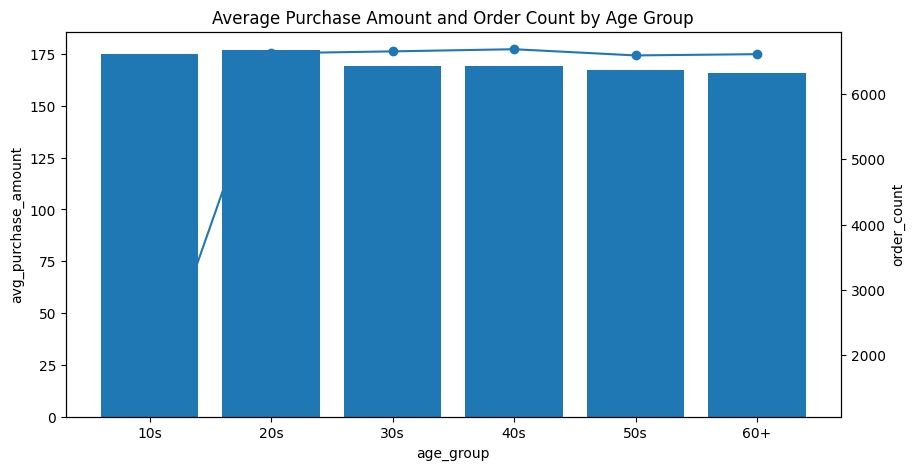

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(age_stats['age_group'].astype(str), age_stats['avg_purchase_amount'])
ax1.set_xlabel('age_group')
ax1.set_ylabel('avg_purchase_amount')

ax2 = ax1.twinx()
ax2.plot(age_stats['age_group'].astype(str), age_stats['order_count'], marker='o')
ax2.set_ylabel('order_count')

plt.title('Average Purchase Amount and Order Count by Age Group')
plt.show()


## 3. Customer Aggregation and RFM Analysis

The original notebooks computed customer-level summary tables and a quartile-based RFM score.

For the final portfolio version, I used the **report-aligned weighted RFM logic**:
- **Recency**: 5-level rule based on purchase recency
- **Frequency**: simplified 3-level rule because most customers purchase only 1 to 3 times
- **Monetary**: quantile-based scoring to better capture the long-tail high spenders
- **Weighted score**: **R : F : M = 2 : 1 : 4**


In [ ]:
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

customer_summary = (
    df.groupby('customer_id')
      .agg(
          Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
          Frequency=('order_id', 'nunique'),
          Monetary=('total_amount', 'sum')
      )
      .reset_index()
)

customer_summary.head()


,customer_id,Recency,Frequency,Monetary
0,C10000,5,2,210.58
1,C10001,194,5,3246.02
2,C10002,401,5,216.85
3,C10003,72,3,154.30
4,C10004,600,3,716.99


In [ ]:
top_5_customers = customer_summary.sort_values('Monetary', ascending=False).head(5)
top_5_customers


,customer_id,Recency,Frequency,Monetary
6572,C16655,63,10,13885.10
3526,C13565,55,5,11984.28
5313,C15379,28,3,11375.58
7028,C17116,456,5,7424.34
5574,C15644,102,7,7244.07


In [ ]:
monetary_quantiles = customer_summary['Monetary'].quantile([0.20, 0.50, 0.80, 0.95])
monetary_quantiles


0.20     173.562
0.50     494.450
0.80    1134.756
0.95    2286.392
Name: Monetary, dtype: float64

In [ ]:
def score_recency(x):
    if x <= 30:
        return 5
    elif x <= 60:
        return 4
    elif x <= 120:
        return 3
    elif x <= 180:
        return 2
    return 1

q20 = customer_summary['Monetary'].quantile(0.20)
q50 = customer_summary['Monetary'].quantile(0.50)
q80 = customer_summary['Monetary'].quantile(0.80)
q95 = customer_summary['Monetary'].quantile(0.95)

def score_monetary(x):
    if x >= q95:
        return 5
    elif x >= q80:
        return 4
    elif x >= q50:
        return 3
    elif x >= q20:
        return 2
    return 1

def score_frequency(x):
    if x >= 3:
        return 3
    elif x >= 2:
        return 2
    return 1

customer_summary['R_Score'] = customer_summary['Recency'].apply(score_recency)
customer_summary['F_Score'] = customer_summary['Frequency'].apply(score_frequency)
customer_summary['M_Score'] = customer_summary['Monetary'].apply(score_monetary)

customer_summary['Weighted_RFM_Score'] = (
    customer_summary['R_Score'] * 2 +
    customer_summary['F_Score'] * 1 +
    customer_summary['M_Score'] * 4
)

customer_summary[['customer_id', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'Weighted_RFM_Score']].head()


,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Weighted_RFM_Score
0,C10000,5,2,210.58,5,2,2,20
1,C10001,194,5,3246.02,1,3,5,25
2,C10002,401,5,216.85,1,3,2,13
3,C10003,72,3,154.30,3,3,1,13
4,C10004,600,3,716.99,1,3,3,17


In [ ]:
def assign_segment(score):
    if 7 <= score <= 15:
        return 'Churned'
    elif 16 <= score <= 20:
        return 'General'
    elif 21 <= score <= 25:
        return 'Excellent'
    return 'VIP'

customer_summary['Segment'] = customer_summary['Weighted_RFM_Score'].apply(assign_segment)
customer_summary['Segment'].value_counts()


Segment
Churned      2685
Excellent    2435
General      1988
VIP           795
Name: count, dtype: int64

In [ ]:
segment_analysis = (
    customer_summary.groupby('Segment')
      .agg(
          customer_count=('customer_id', 'nunique'),
          avg_recency=('Recency', 'mean'),
          avg_frequency=('Frequency', 'mean'),
          avg_monetary=('Monetary', 'mean'),
          total_revenue=('Monetary', 'sum')
      )
      .reset_index()
)

segment_analysis['revenue_contribution_pct'] = (
    segment_analysis['total_revenue'] / segment_analysis['total_revenue'].sum() * 100
)

segment_order = ['Churned', 'General', 'Excellent', 'VIP']
segment_analysis['Segment'] = pd.Categorical(segment_analysis['Segment'], categories=segment_order, ordered=True)
segment_analysis = segment_analysis.sort_values('Segment').reset_index(drop=True)
segment_analysis


,Segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_contribution_pct
0,Churned,2685,259.361639,2.940410,195.219818,524165.21,8.936727
1,General,1988,157.951207,4.232394,540.761579,1075034.02,18.328735
2,Excellent,2435,86.092402,5.388501,1003.611918,2443795.02,41.665352
3,VIP,795,46.057862,6.377358,2292.199748,1822298.80,31.069186


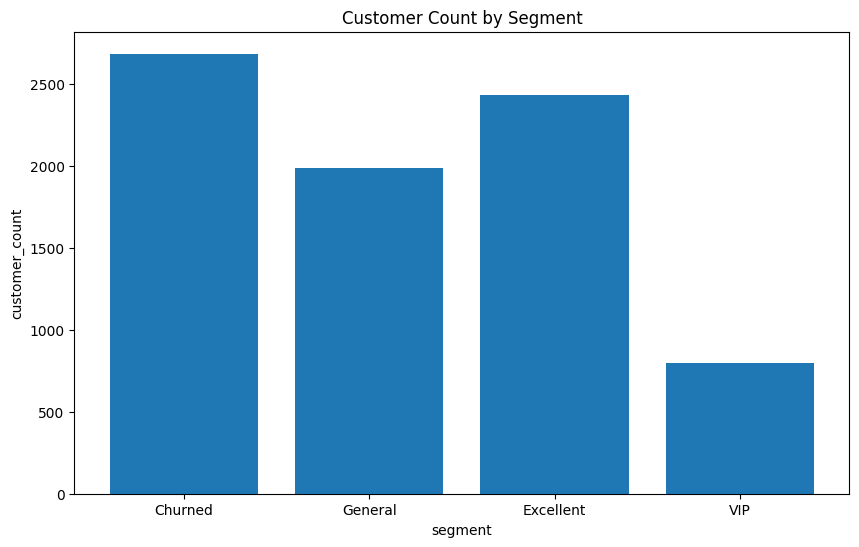

In [ ]:
plt.figure()
plt.bar(segment_analysis['Segment'].astype(str), segment_analysis['customer_count'])
plt.title('Customer Count by Segment')
plt.xlabel('segment')
plt.ylabel('customer_count')
plt.show()


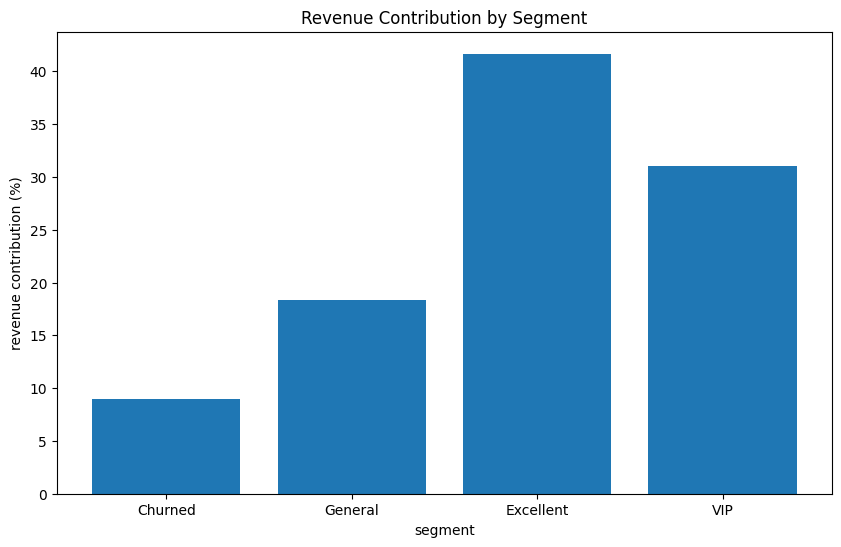

In [ ]:
plt.figure()
plt.bar(segment_analysis['Segment'].astype(str), segment_analysis['revenue_contribution_pct'])
plt.title('Revenue Contribution by Segment')
plt.xlabel('segment')
plt.ylabel('revenue contribution (%)')
plt.show()


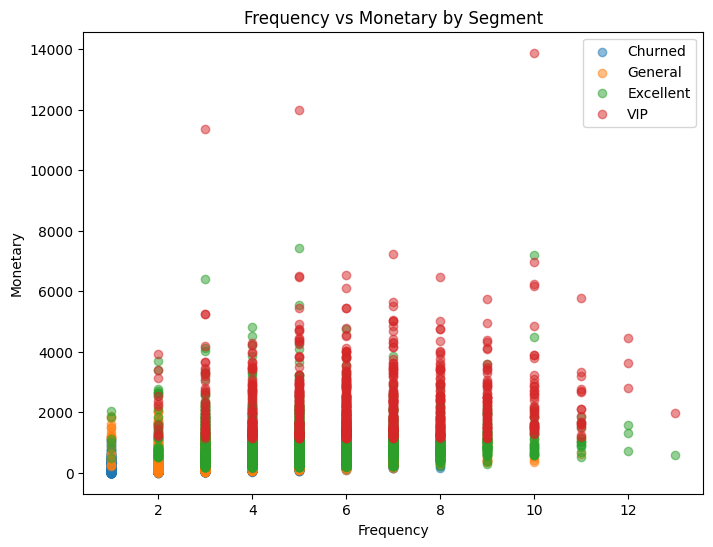

In [ ]:
plt.figure(figsize=(8, 6))
for seg_name in ['Churned', 'General', 'Excellent', 'VIP']:
    temp = customer_summary[customer_summary['Segment'] == seg_name]
    plt.scatter(temp['Frequency'], temp['Monetary'], label=seg_name, alpha=0.5)

plt.title('Frequency vs Monetary by Segment')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.legend()
plt.show()


## 4. Key Findings

This section turns the notebook into something interview-ready.  
The point is not just to show code, but to show what the analysis means.


In [ ]:
top_10pct_n = int(np.ceil(len(customer_summary) * 0.10))
top_10pct_revenue_share = (
    customer_summary.sort_values('Monetary', ascending=False)
                    .head(top_10pct_n)['Monetary']
                    .sum()
    / customer_summary['Monetary'].sum()
    * 100
)

findings = pd.DataFrame({
    'finding': [
        'Average purchase amount is highest in West and South',
        'Electronics dominates revenue across all regions',
        'Gender revenue share is nearly balanced',
        'Customers in their 20s show the strongest activity',
        'Excellent and VIP segments drive most revenue',
        'Top 10% customers account for a large share of revenue'
    ],
    'value': [
        ', '.join(region_avg.head(2)['region'].tolist()),
        df.pivot_table(index='region', columns='category', values='total_amount', aggfunc='sum').idxmax(axis=1).mode()[0],
        f"{gender_share.to_dict()}",
        age_stats.sort_values(['avg_purchase_amount', 'order_count'], ascending=False).iloc[0]['age_group'],
        f"{segment_analysis.loc[segment_analysis['Segment'].isin(['Excellent', 'VIP']), 'revenue_contribution_pct'].sum():.1f}%",
        f"{top_10pct_revenue_share:.1f}%"
    ]
})
findings


,finding,value
0,Average purchase amount is highest in West and...,"West, South"
1,Electronics dominates revenue across all regions,Electronics
2,Gender revenue share is nearly balanced,"{'Female': 48.6, 'Male': 47.6, 'Other': 3.7}"
3,Customers in their 20s show the strongest acti...,20s
4,Excellent and VIP segments drive most revenue,72.7%
5,Top 10% customers account for a large share of...,35.6%


## 5. Business Recommendations

### 1) Protect VIP customers
- VIP customers are a small group but contribute a very large share of revenue.
- Priority actions: exclusive benefits, early access, loyalty perks, premium support.

### 2) Upgrade Excellent customers into VIP
- Excellent customers already generate the largest revenue share.
- Priority actions: upselling, cross-selling, bundle recommendations, tier-up incentives.

### 3) Reactivate Churned customers
- Churned customers have high recency and low purchase frequency.
- Priority actions: win-back coupon, personalized reminders, limited-time comeback campaign.

### 4) Focus category and age targeting
- Electronics is the strongest revenue category.
- Customers in their 20s show strong spending and order activity.
- Priority actions: targeted campaigns for high-value categories and active age segments.


## Appendix: What was preserved from the original notebooks

Useful parts preserved and reorganized:
- transaction-level EDA
- box plots for numeric variables
- category order analysis
- gender revenue share analysis
- customer-level aggregation
- RFM scoring logic
- segment-level revenue analysis

Excluded or rewritten:
- duplicated cells
- cells executed in the wrong order
- environment-specific installation commands
- unrelated notebook content based on a different dataset
